In [ ]:
from __future__ import annotations
from typing import Any
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import math
from math import pi, sqrt

import scipy as sp
from scipy.integrate import simpson

d = 3 # Number of fock states to include

omega_q = 1 # GHz
omega_d = 1
anharmonicity = -0.4 # 400 MHz
alpha = 2*pi*anharmonicity

# Width of control pulse
tg = 10 # ns
t_pad = 0.1 # Add 0 strength sections to front and end of pulses (is this needed?)
t_array = np.linspace(-t_pad, tg+t_pad, 100)

ad = qt.create(d)
a = qt.destroy(d)

def sigma_x(i, j):
    return qt.projection(d, i, j) + qt.projection(d, j, i)

def sigma_y(i, j):
    return 1j * (qt.projection(d, i, j) - qt.projection(d, j, i))

def H_R_func(t, args:dict[str, Any]):
    fI = args['fI'](t) if 'fI' in args else 0
    fQ = args['fQ'](t) if 'fI' in args else 0
    return (qt.qdiags([(omega_q-omega_d)*i + alpha/2 * i*(i-1) for i in range(d)])
            + fI/2 * sum([sqrt(i)*sigma_x(i-1, i) for i in range(1, d)])
            + fQ/2 * sum([sqrt(i)*sigma_y(i-1, i) for i in range(1, d)]))


# Control pulse for a square cutoff
def fI_window(t, tg):
    flag = (t >= 0) * (t < tg)
    return flag * 1/tg

# Control pulse for gaussian
def fI_gaussian(t, tg, sigma):
    flag = (t >= 0) * (t < tg)
    B = np.exp(-(tg**2) / (8*sigma**2))
    return flag * (np.exp(-(t-tg/2)**2 / (2*sigma**2)) - B) / (sqrt(2*pi)*sigma*math.erf(tg / (sqrt(8)*sigma)) - tg*B)


def is_dm(obj:qt.Qobj):
    """Returns True if the object is a density matrix."""
    return obj.isoper and obj.isherm and np.abs(obj.tr() - 1) <= 1e-10

def L(state:qt.Qobj):
    """Returns 'Leakage' of a given state, defined as trace of projecting into the non-computational subspace."""
    if is_dm(state):
        rho = state
    else:
        rho = qt.ket2dm(state)

    return 1 - np.abs(rho[0,0] + rho[1,1])

In [58]:
psi0 = qt.basis(d, 0)

H_R = qt.QobjEvo(H_R_func, args={'fI': lambda t: pi*fI_window(t, tg), 'fQ': lambda t: 0})
result = qt.sesolve(H_R, psi0, t_array)
display(result.final_state)
print(f"Leakage = {L(result.final_state):.4f}")

Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[-0.57400519+0.18410216j]
 [-0.65914787-0.43960801j]
 [-0.09205138-0.02049053j]]

Leakage = 0.0089


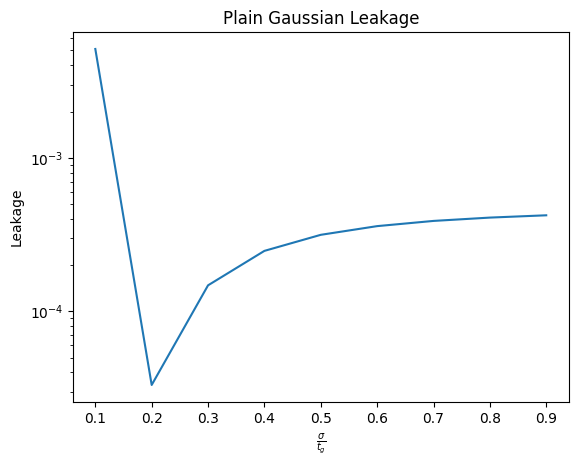

In [59]:
sigma_array = np.arange(0.1, 1, 0.1) * tg

#fI_array = fI_gaussian(t_array, tg, 0.5*tg)
#print(f"Area = {simpson(fI_array, t_array)}")
#plt.plot(t_array, fI_array)
#plt.show()

leakage_array2 = np.zeros_like(sigma_array)

psi0 = qt.basis(d, 0)

for i, sigma in enumerate(sigma_array):
    # print(f"sigma = {sigma}")
    # fI_array = pi*fI_gaussian(t_array, tg, sigma)
    # plt.plot(t_array, fI_array)
    # plt.show()

    H_R_gaussian = qt.QobjEvo(H_R_func, args={'fI': lambda t: pi*fI_gaussian(t, tg, sigma), 'fQ': lambda t: 0})
    result = qt.sesolve(H_R_gaussian, psi0, t_array)
    leakage = L(result.final_state)
    leakage_array2[i] = leakage

plt.semilogy(sigma_array/tg, leakage_array2)
plt.xlabel(r"$\frac{\sigma}{t_g}$")
plt.ylabel("Leakage")
plt.title("Plain Gaussian Leakage")
plt.show()

Plot leakage for different gate times for plain Gaussian

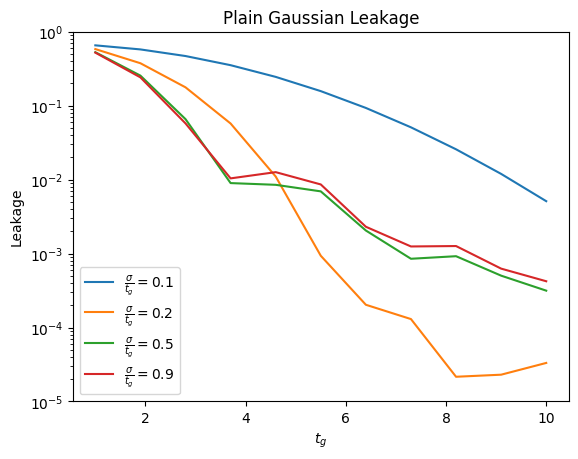

In [60]:
tg_array = np.linspace(1, 10, 11) # ns
sigma_array = np.array([0.1, 0.2, 0.5, 0.9])

leakage_array2 = np.zeros([len(tg_array), len(sigma_array)])

for i, tg in enumerate(tg_array):
    for j, sigma_scalar in enumerate(sigma_array):
        sigma = sigma_scalar * tg
        t_array = np.linspace(-t_pad, tg+t_pad, 100)

        H_R_gaussian = qt.QobjEvo(H_R_func, args={'fI': lambda t: pi*fI_gaussian(t, tg, sigma), 'fQ': lambda t: 0})
        result = qt.sesolve(H_R_gaussian, psi0, t_array)
        leakage = L(result.final_state)
        leakage_array2[i, j] = leakage

plt.semilogy(tg_array, leakage_array2)
plt.xlabel(r"$t_g$")
plt.ylabel("Leakage")
plt.ylim(1e-5, 1)
plt.title("Plain Gaussian Leakage")
plt.legend([fr"$\frac{{\sigma}}{{t_g}}={s}$" for s in sigma_array])
plt.show()